In [36]:
!pip install kagglehub

In [37]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Dataset path:", path)

# Go inside UTKFace folder
path = os.path.join(path, "UTKFace")

print("Images path:", path)
print("Number of files:", len(os.listdir(path)))

Using Colab cache for faster access to the 'utkface-new' dataset.
Dataset path: /kaggle/input/utkface-new
Images path: /kaggle/input/utkface-new/UTKFace
Number of files: 23708


In [39]:
# Load images and label
image_paths = []
ages = []
genders = []

for file in os.listdir(path):

    try:

        # Extract age
        age = int(file.split("_")[0])

        # Extract gender
        gender = int(file.split("_")[1])

        # Full image path
        image_path = os.path.join(path, file)

        image_paths.append(image_path)
        ages.append(age)
        genders.append(gender)

    except:

        continue


In [40]:
df = pd.DataFrame({
    "image_path": image_paths,
    "age": ages,
    "gender": genders
})

In [41]:
print("Total valid images:", len(df))

df.head()

Total valid images: 23708


,image_path,age,gender
0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...,26,0
1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...,22,1
2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...,21,1
3,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...,28,0
4,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...,17,1


In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  23708 non-null  object
 1   age         23708 non-null  int64 
 2   gender      23708 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 555.8+ KB


In [43]:
print(df["gender"].value_counts())

gender
0    12391
1    11317
Name: count, dtype: int64


In [44]:
print(df["age"].describe())

count    23708.000000
mean        33.303484
std         19.886112
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


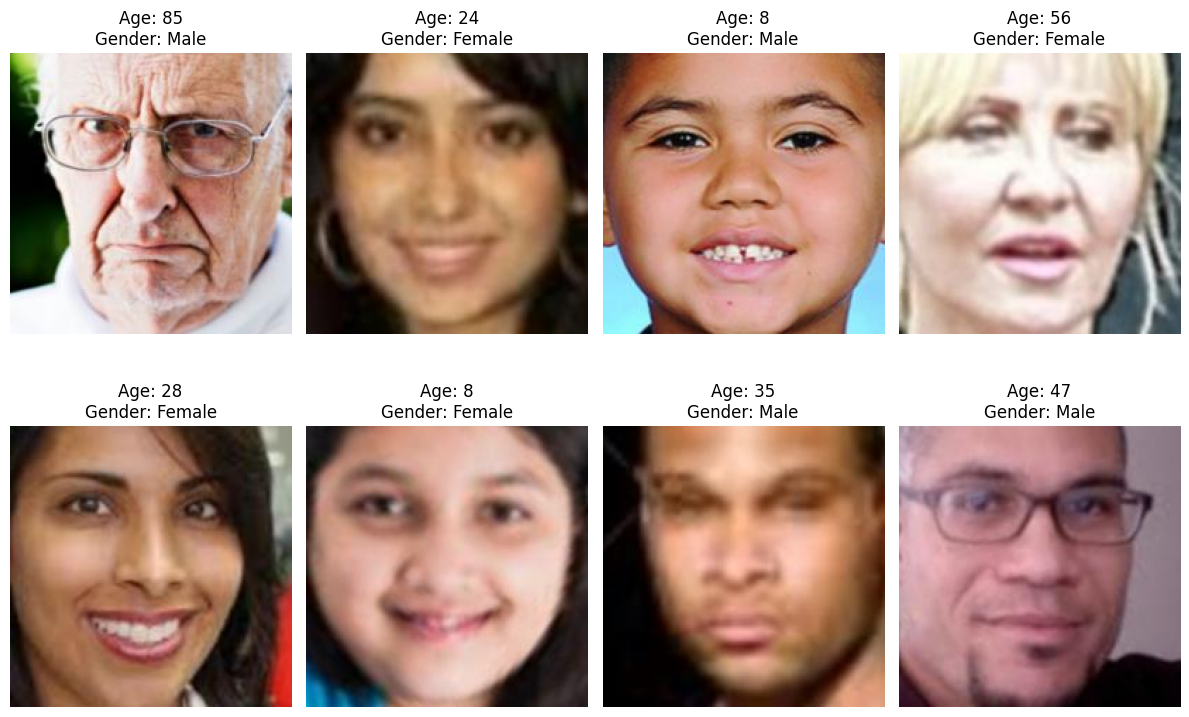

In [45]:
plt.figure(figsize=(12, 8))

sample_df = df.sample(8, random_state=42)

for i, (_, row) in enumerate(sample_df.iterrows()):

    image = plt.imread(row["image_path"])

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    gender = "Male" if row["gender"] == 0 else "Female"

    plt.title(
        f"Age: {row['age']}\nGender: {gender}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["gender"]
)

In [47]:
print("Training:", len(train_df))
print("Testing:", len(test_df))

Training: 18966
Testing: 4742


In [48]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 8

In [49]:
def load_image(image_path, age, gender):

    # Read image
    image = tf.io.read_file(image_path)

    # Decode JPEG
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # VGG16 preprocessing
    image = preprocess_input(image)

    return image, {
        "age": age,
        "gender": gender
    }

In [50]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["age"].values.astype("float32"),
        train_df["gender"].values.astype("float32")
    )
)

In [51]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [52]:
train_dataset = train_dataset.batch(
    BATCH_SIZE
)

In [53]:
train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [54]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["age"].values.astype("float32"),
        test_df["gender"].values.astype("float32")
    )
)

In [55]:
test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [56]:
images, labels = next(iter(train_dataset))

print("Images:", images.shape)

print("Age:", labels["age"].shape)

print("Gender:", labels["gender"].shape)

Images: (8, 224, 224, 3)
Age: (8,)
Gender: (8,)


In [57]:
#Create VGG16
inputs = Input(
    shape=(224, 224, 3)
)
vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_tensor=inputs
)
vgg.trainable =False

In [58]:
#Create a dense layer
x = GlobalAveragePooling2D()(vgg.output)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

In [59]:
age_output = Dense(
    1,
    activation="linear",
    name="age"
)(x)
gender_output = Dense(
    1,
    activation="sigmoid",
    name="gender"
)(x)

In [60]:
#Create a functional Model
model = Model(
    inputs=inputs,
    outputs=[
        age_output,
        gender_output
    ]
)


In [61]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 14,846,530 (56.64 MB)

 Trainable params: 131,842 (515.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [62]:
model.compile(
    optimizer="adam",

    loss={
        "age": "mse",
        "gender": "binary_crossentropy"
    },

    metrics={
        "age": "mae",
        "gender": "accuracy"
    }
)

In [63]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
2371/2371 ━━━━━━━━━━━━━━━━━━━━ 174s 70ms/step - age_loss: 187.7669 - age_mae: 10.2995 - gender_accuracy: 0.7297 - gender_loss: 0.6483 - loss: 188.4301 - val_age_loss: 151.6160 - val_age_mae: 9.0199 - val_gender_accuracy: 0.8051 - val_gender_loss: 0.4317 - val_loss: 152.0806
Epoch 2/5
2371/2371 ━━━━━━━━━━━━━━━━━━━━ 167s 70ms/step - age_loss: 154.2927 - age_mae: 9.3184 - gender_accuracy: 0.7736 - gender_loss: 0.4925 - loss: 154.7928 - val_age_loss: 143.2018 - val_age_mae: 8.7849 - val_gender_accuracy: 0.8047 - val_gender_loss: 0.4246 - val_loss: 143.6605
Epoch 3/5
2371/2371 ━━━━━━━━━━━━━━━━━━━━ 157s 66ms/step - age_loss: 145.2981 - age_mae: 9.0524 - gender_accuracy: 0.7705 - gender_loss: 0.4896 - loss: 145.7955 - val_age_loss: 142.5647 - val_age_mae: 8.6496 - val_gender_accuracy: 0.8045 - val_gender_loss: 0.4210 - val_loss: 143.0122
Epoch 4/5
2371/2371 ━━━━━━━━━━━━━━━━━━━━ 157s 66ms/step - age_loss: 139.2025 - age_mae: 8.8288 - gender_accuracy: 0.7802 - gender_loss: 0.4762 - lo

In [105]:
model.evaluate(test_dataset)

593/593 ━━━━━━━━━━━━━━━━━━━━ 37s 62ms/step - age_loss: 136.6858 - age_mae: 8.4487 - gender_accuracy: 0.8073 - gender_loss: 0.4061 - loss: 137.1147


[137.11471557617188,
 136.68576049804688,
 0.4060731530189514,
 8.448732376098633,
 0.8072543144226074]

In [65]:
images, labels = next(iter(test_dataset))

In [103]:
age_pred, gender_pred = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [106]:
print("Actual Age:", labels["age"][0].numpy())

print(
    "Predicted Age:",
    round(float(age_pred[0][0]))
)

print(
    "Actual Gender:",
    "Male" if labels["gender"][0] == 0 else "Female"
)

print(
    "Predicted Gender:",
    "Male" if gender_pred[0][0] < 0.5 else "Female"
)

Actual Age: 35.0
Predicted Age: 35
Actual Gender: Male
Predicted Gender: Male


In [108]:
from PIL import Image


In [109]:
model.save("best_model.keras")

In [135]:
image_path = '/content/haha.webp'

In [136]:
image = Image.open(image_path).convert("RGB")

image = image.resize((224, 224))

image_array = np.array(image)

image_array = preprocess_input(image_array)

image_array = np.expand_dims(image_array, axis=0)

print(image_array.shape)

(1, 224, 224, 3)


In [137]:
age_prediction, gender_prediction = model.predict(image_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


In [138]:
age = round(float(age_prediction[0][0]))

gender_probability = float(gender_prediction[0][0])

if gender_probability < 0.5:
    gender = "Male"
else:
    gender = "Female"

print("Predicted Age:", age)
print("Predicted Gender:", gender)

Predicted Age: 18
Predicted Gender: Male


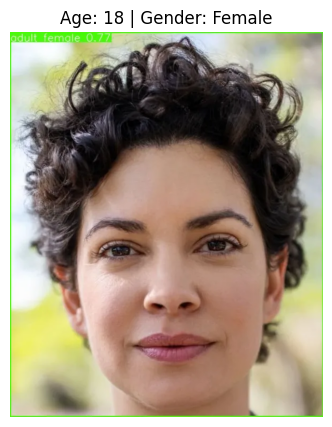

In [144]:
plt.figure(figsize=(5, 5))

plt.imshow(Image.open(image_path))
plt.title(f"Age: {age} | Gender: {gender}")

plt.axis("off")
plt.show()

In [140]:
image_path1 = '/content/girl.avif'

img1 = tf.keras.utils.load_img(
    image_path1,
    target_size=(224, 224)
)

imgg = tf.keras.utils.img_to_array(img1)

imgg = preprocess_input(imgg)

imgg = np.expand_dims(imgg, axis=0)

print(imgg.shape)

(1, 224, 224, 3)


In [141]:
prediction = model.predict(imgg)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[array([[17.66181]], dtype=float32), array([[0.94906104]], dtype=float32)]


In [131]:
age_prediction = prediction[0][0][0]

print("Predicted Age:", age_prediction)

Predicted Age: 17.66181


In [142]:
gender_probability = prediction[1][0][0]
if gender_probability < 0.5:
    gender = "Male"
else:
    gender = "Female"

print("Predicted Age:", age)
print("Predicted Gender:", gender)

print("Gender Probability:", gender_probability)

Predicted Age: 18
Predicted Gender: Female
Gender Probability: 0.94906104


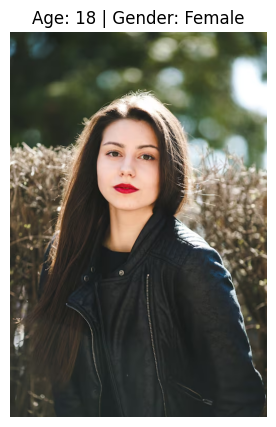

In [143]:
plt.figure(figsize=(5, 5))

plt.imshow(Image.open(image_path1))
plt.title(f"Age: {age} | Gender: {gender}")

plt.axis("off")
plt.show()